# Social Progress Index Rankings Data Analysis

## Install dependencies

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn

## Dataset

In [134]:
df = pd.read_csv("../../datasets/Social Progress Index 2022.csv")

print("First 5 records:", df.head(3))

First 5 records:    Rank  Country  Social Progress Score  Basic Human Needs  \
0     1   Norway                  90.74              91.26   
1     2  Denmark                  90.54              91.81   
2     3  Finland                  90.46              91.36   

   Foundations of Wellbeing  Opportunity  Nutrition and Basic Medical Care  \
0                     90.86        90.11                             93.89   
1                     90.32        89.48                             95.33   
2                     90.31        89.71                             93.22   

   Water and Sanitation  Shelter  Personal Safety  Access to Basic Knowledge  \
0                 98.80    91.59            80.76                      98.69   
1                 97.36    94.32            80.22                      97.47   
2                 98.45    95.79            77.98                      96.31   

   Access to Information and Communications  Health and Wellness  \
0                               

In [135]:
print("Shape:", df.shape)
print("Number of Null values:")
print(df.isnull().sum())

Shape: (169, 18)
Number of Null values:
Rank                                        0
Country                                     0
Social Progress Score                       0
Basic Human Needs                           0
Foundations of Wellbeing                    0
Opportunity                                 0
Nutrition and Basic Medical Care            0
Water and Sanitation                        0
Shelter                                     0
Personal Safety                             0
Access to Basic Knowledge                   0
Access to Information and Communications    0
Health and Wellness                         0
Environmental Quality                       0
Personal Rights                             0
Personal Freedom and Choice                 0
Inclusiveness                               0
Access to Advanced Education                0
dtype: int64


In [136]:
print("Data types:")
print(df.dtypes)

Data types:
Rank                                          int64
Country                                         str
Social Progress Score                       float64
Basic Human Needs                           float64
Foundations of Wellbeing                    float64
Opportunity                                 float64
Nutrition and Basic Medical Care            float64
Water and Sanitation                        float64
Shelter                                     float64
Personal Safety                             float64
Access to Basic Knowledge                   float64
Access to Information and Communications    float64
Health and Wellness                         float64
Environmental Quality                       float64
Personal Rights                             float64
Personal Freedom and Choice                 float64
Inclusiveness                               float64
Access to Advanced Education                float64
dtype: object


## K-means and variations

In [137]:
kmeans = sklearn.cluster.KMeans(
    n_clusters=8, 
    init='random', 
    verbose=0, 
    random_state=42, 
    copy_x=True
)
kmeanspp = sklearn.cluster.KMeans(
    n_clusters=8, 
    init='k-means++', 
    verbose=0, 
    random_state=42, 
    copy_x=True
)
kmeans_small = sklearn.cluster.KMeans(
    n_clusters=4, 
    init='random', 
    verbose=0, 
    random_state=42, 
    copy_x=True
)

In [138]:
kmeanspp.fit_predict(df.drop(columns=['Rank', 'Country']))
country_clusters = pd.DataFrame({'Rank': df['Rank'], 'Country': df['Country'], 'Cluster': kmeanspp.labels_})
country_clusters.head()


,Rank,Country,Cluster
0,1,Norway,2
1,2,Denmark,2
2,3,Finland,2
3,4,Switzerland,2
4,5,Iceland,2


In [139]:
cluster_1 = country_clusters[country_clusters['Cluster'] == 1]
cluster_2 = country_clusters[country_clusters['Cluster'] == 2]
cluster_3 = country_clusters[country_clusters['Cluster'] == 3]
cluster_4 = country_clusters[country_clusters['Cluster'] == 4]

In [140]:
print(cluster_2)

    Rank             Country  Cluster
0      1              Norway        2
1      2             Denmark        2
2      3             Finland        2
3      4         Switzerland        2
4      5             Iceland        2
5      6              Sweden        2
6      7         Netherlands        2
7      8             Germany        2
8      9               Japan        2
9     10              Canada        2
10    11             Austria        2
11    12           Australia        2
12    13             Ireland        2
13    14          Luxembourg        2
14    15         New Zealand        2
15    16             Belgium        2
16    17  Korea, Republic of        2
17    18             Estonia        2
18    19      United Kingdom        2
19    20              France        2
20    21               Spain        2
21    22               Italy        2
22    23             Czechia        2
23    24            Portugal        2
24    25       United States        2
25    26    

In [141]:
cluster_7 = country_clusters[country_clusters['Cluster'] == 7]
print(cluster_7)

     Rank                   Country  Cluster
158   159                     Niger        7
161   162                    Guinea        7
164   165                   Somalia        7
165   166                   Eritrea        7
166   167                      Chad        7
167   168  Central African Republic        7
168   169               South Sudan        7


Cluster 2 contains some of the highest ranked countries while Cluster 7 contains some of the lowest ranked countries. This is expected as the highest ranked countries in the Social Progress Index should have similar scores, and are thereby grouped together by K-means algorithm

### Comparing K-means settings

In [142]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

X = df.drop(columns=['Rank', 'Country'])
ks = [2, 3, 5, 10, 15]
inits = ['random', 'k-means++']

models = {
    (k, init): sklearn.cluster.KMeans(
        n_clusters=k,
        init=init,
        verbose=0,
        random_state=42,
        copy_x=True
    ).fit(X)
    for k in ks for init in inits
}

In [143]:
results = pd.DataFrame([
    {
        "k": k,
        "init": init,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X, model.labels_),
        "Davies-Bouldin": davies_bouldin_score(X, model.labels_),
        "Iterations": model.n_iter_,
    }
    for (k, init), model in models.items()
])
results

,k,init,Inertia,Silhouette,Davies-Bouldin,Iterations
0,2,random,356747.721283,0.453410,0.843497,5
1,2,k-means++,356747.721283,0.453410,0.843497,5
2,3,random,224403.015951,0.410714,0.869641,12
3,3,k-means++,224403.015951,0.410714,0.869641,6
4,5,random,161042.599474,0.326071,1.270430,10
5,5,k-means++,160862.647802,0.337553,1.219422,7
6,10,random,110715.710067,0.217272,1.297350,6
7,10,k-means++,110131.307655,0.215872,1.353145,7
8,15,random,90751.313019,0.194503,1.288623,7
9,15,k-means++,88813.769243,0.202873,1.422589,6


In [144]:
agreement = pd.Series({
    k: adjusted_rand_score(models[(k, 'random')].labels_, models[(k, 'k-means++')].labels_)
    for k in ks
}, name="ARI (random vs k-means++)")
agreement

2     1.000000
3     1.000000
5     0.845321
10    0.645369
15    0.623002
Name: ARI (random vs k-means++), dtype: float64

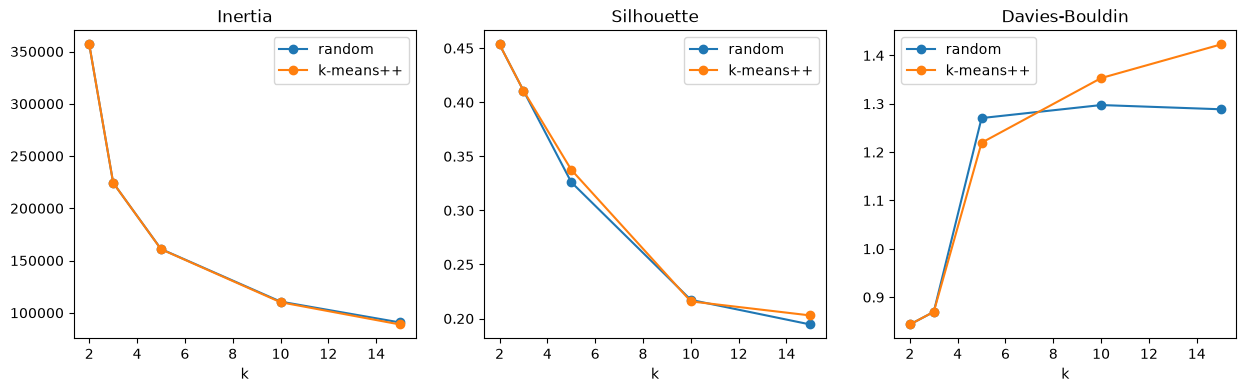

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for init in inits:
    subset = results[results['init'] == init]
    axes[0].plot(subset['k'], subset['Inertia'], marker='o', label=init)
    axes[1].plot(subset['k'], subset['Silhouette'], marker='o', label=init)
    axes[2].plot(subset['k'], subset['Davies-Bouldin'], marker='o', label=init)
for ax, title in zip(axes, ["Inertia", "Silhouette", "Davies-Bouldin"]):
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.legend()
plt.show()

Findings:
- K-means++ gives slightly better inertia scores than K-means
- Silhouette and Davies-Bouldin scores get worse as K increases suggesting that the Social Progress Index scores of countries do not form clearly separated groups
- Random and k-means++ give identical results for k=2 and k=3 (ARI = 1.0), but disagree more as k grows (ARI 0.85 at k=5, about 0.62 to 0.65 at k=10 and k=15)

## Agglomerative Clustering